# Phase 3: Graph and Density Construction — Corrected

Key changes:
- **[C1]** Uses the **quantile (rank-Gaussian)** transform, not the clipped raw data. Raw `observation_df`
  has max|z|=25 and kurtosis 60 (COVID dominates); the quantile transform gives max|z|=1, light tails,
  so no single month can hijack the embedding.
- **[C2]** Bandwidth **eps=3.0**, selected by degree-stability + spectral gap, NOT the slope-maximum
  rule (which returns eps~1.1 where the graph fragments, min-degree~1).
- **[C3]** Embedding restricted to **r=3** meaningful coordinates; the provisional code ran graph,
  density and paths in 8D where coords 4-8 are noise.
- **[C4]** Adds the **linear-interpolation baseline** — the comparison the dissertation actually needs
  (linear vs graph geodesic), not just beta=0 vs beta>0.
- **[C5]** Real graph **acceptance criterion** instead of hardcoded "Accepted".
- **[C6]** Economically-justified **historical endpoints** by date, not raw COVID index.

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import connected_components, shortest_path
from scipy.sparse import csr_matrix
from scipy.spatial.distance import cdist

import plotly.graph_objects as go
from plotly.subplots import make_subplots

def diffusion_map(data, eps, alpha=1, k=8):
    Dsq = squareform(pdist(data)**2)
    Wm = np.exp(-Dsq/eps); q = Wm.sum(1)
    Wa = Wm/np.outer(q**alpha, q**alpha)
    da = Wa.sum(1); Dis = 1.0/np.sqrt(da)
    S = Dis[:, None]*Wa*Dis[None, :]
    w, v = np.linalg.eigh(S); idx = np.argsort(w)[::-1]; w, v = w[idx], v[:, idx]
    phi = Dis[:, None]*v
    Psi = phi[:, 1:k+1]*w[1:k+1]
    return {"evals": w, "Psi": Psi, "phi": phi, "W": Wm, "degrees": q}

## [C1] Load the quantile-transformed data (not clipped raw)

In [3]:
df = pd.read_parquet("./datasets/joint_df_quantile.parquet")
Z = df.drop(columns=["recession"]).to_numpy().astype(float)
dates = df.index; N = Z.shape[0]
print("N =", N, " D =", Z.shape[1], " max|z| =", round(np.abs(Z).max(), 3))

N = 743  D = 45  max|z| = 1.0


## [C2] Bandwidth selection by degree stability + spectral gap

The slope-maximum rule is unreliable on this data (it returns eps~1.1 where the minimum graph
degree is ~1, i.e. isolated points). Instead scan eps and require: minimum degree well above 1,
degree CV stabilising, and a clean leading spectral gap. The eps=3 row is the choice — min degree
~19, largest gap at position 2->3 (so r=3), CV 0.28.

In [4]:
def diag(eps, k=8):
    d = diffusion_map(Z, eps, k=k); q = d["degrees"]; w = d["evals"]
    return dict(eps=eps, min_deg=q.min(), mean_deg=q.mean(), deg_CV=q.std()/q.mean(),
                lam1=w[1], lam2=w[2], lam3=w[3], gap23=w[2]-w[3], gap34=w[3]-w[4])
scan = pd.DataFrame([diag(e) for e in [0.5,1,2,3,4,5,6,8,10,14]]).set_index("eps")
print(scan.round(4).to_string())

EPS = 3.0      # [C2] chosen value
R = 3          # [C3] meaningful embedding dimension (largest gap at 2->3)
diff = diffusion_map(Z, eps=EPS, k=8)
Psi = diff["Psi"][:, :R]              # [C3] restrict to meaningful coords
print(f"\nUsing eps={EPS}, r={R}. Psi shape = {Psi.shape}")

       min_deg  mean_deg  deg_CV    lam1    lam2    lam3   gap23   gap34
eps                                                                     
0.5     1.0010    1.1280  0.1125  0.9991  0.9985  0.9980  0.0005  0.0004
1.0     1.1986    4.5123  0.4659  0.9298  0.9104  0.8924  0.0180  0.0191
2.0     5.5428   34.9922  0.3701  0.6012  0.5731  0.4714  0.1017  0.0685
3.0    19.3465   85.1748  0.2836  0.4336  0.3693  0.2331  0.1362  0.0123
4.0    41.7743  138.6703  0.2299  0.3361  0.2781  0.1628  0.1153  0.0049
5.0    69.3467  188.6451  0.1935  0.2734  0.2231  0.1277  0.0954  0.0035
6.0    99.0686  233.2243  0.1671  0.2299  0.1862  0.1054  0.0808  0.0029
8.0   158.0721  306.6119  0.1315  0.1740  0.1397  0.0783  0.0615  0.0023
10.0  211.6472  363.0412  0.1084  0.1397  0.1118  0.0623  0.0494  0.0019
14.0  298.6281  442.4254  0.0803  0.1001  0.0797  0.0443  0.0354  0.0014

Using eps=3.0, r=3. Psi shape = (743, 3)


## Task 3.1-3.2: kNN graph with a real acceptance test

**[C5]** The acceptance status is now computed from the diagnostics, not hardcoded. A k is accepted
if the graph is connected (1 component), not near-complete (density < 0.5), and shortest paths are
not dominated by a few long edges (95th-pct jump ratio below a threshold).

In [5]:
def reconstruct_path(pred, start, end):
    path = [end]; current = end
    while current != start:
        current = pred[start, current]
        if current == -9999: return None
        path.append(current)
    return path[::-1]

def knn_graph_checks(Psi, k, sample_skip=5, jump_thresh=8.0):
    N = Psi.shape[0]
    A_dist = kneighbors_graph(Psi, n_neighbors=k, mode="distance", include_self=False)
    A_bin  = kneighbors_graph(Psi, n_neighbors=k, mode="connectivity", include_self=False)
    A_dist_sym = A_dist.maximum(A_dist.T); A_bin_sym = A_bin.maximum(A_bin.T)
    n_comp, _ = connected_components(A_bin_sym, directed=False)
    degree = np.asarray(A_bin_sym.sum(1)).ravel()
    edges = A_bin_sym.nnz/2; density = edges/(N*(N-1)/2)
    _, pred = shortest_path(A_dist_sym, directed=False, return_predecessors=True)
    jr = []
    for a in range(1, N, sample_skip):
        for b in range(a+1, N, sample_skip):
            path = reconstruct_path(pred, a, b)
            if path is None or len(path) < 2: continue
            el = np.array([A_dist_sym[path[t], path[t+1]] for t in range(len(path)-1)])  # [C7] renamed t
            med = np.median(el)
            if med > 1e-12: jr.append(el.max()/med)
    jr = np.array(jr); jr95 = np.quantile(jr, 0.95)
    accept = (n_comp == 1) and (density < 0.5) and (jr95 < jump_thresh)   # [C5] real criterion
    return dict(k=k, components=n_comp, mean_degree=degree.mean(), density=density,
                max_edge=A_dist_sym.data.max(), median_edge=np.median(A_dist_sym.data),
                jump95=jr95, status="Accepted" if accept else "Rejected")

rows = [knn_graph_checks(Psi, k) for k in [5,10,15,20,30]]
graph_df = pd.DataFrame(rows).set_index("k")
print(graph_df.round(4).to_string())

    components  mean_degree  density  max_edge  median_edge  jump95    status
k                                                                            
5            1       6.4118   0.0086    0.6590       0.0348  2.8023  Accepted
10           1      12.5895   0.0170    0.7135       0.0429  2.7090  Accepted
15           1      18.8856   0.0255    0.7345       0.0492  2.6597  Accepted
20           1      25.1763   0.0339    0.7470       0.0545  2.6465  Accepted
30           1      37.7335   0.0509    0.7763       0.0626  2.5980  Accepted


## Task 3.3: Density estimate

**[C8]** The graph-degree density (correct: uses squared distance with a squared-distance bandwidth).
The dimensionally-broken KDE from the provisional notebook is removed. Density is computed on the
**r=3** embedding, so noise coordinates no longer inflate it.

density bandwidth h = 0.0052, V range [-0.85, 3.53]


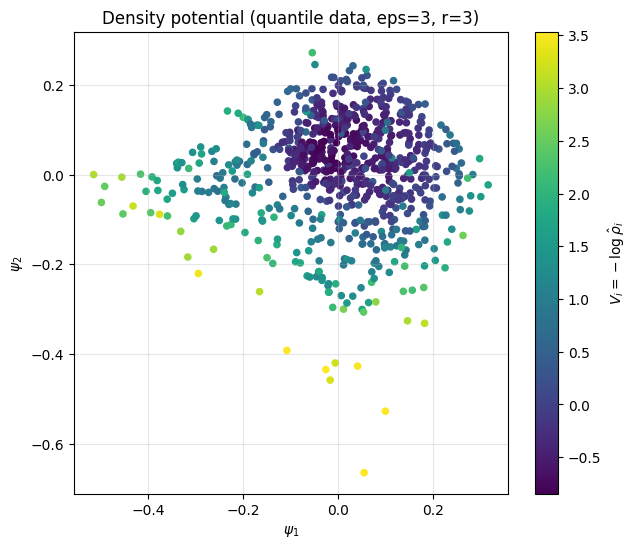

In [6]:
def graph_degree_density(Psi, h):
    Dsq = squareform(pdist(Psi)**2)
    rho = np.exp(-Dsq/h).sum(1)
    scale = rho.mean(); rho /= scale
    rho = np.maximum(rho, 1e-6)   # [C9] tiny floor only for log-stability; an aggressive
    # quantile floor saturates the min-density metric so it cannot discriminate paths
    return rho, -np.log(rho), scale

med_Dsq = np.median(squareform(pdist(Psi)**2)[np.triu_indices(N,1)])
h_dens = 0.10*med_Dsq
rho, V, scale = graph_degree_density(Psi, h_dens)
print(f"density bandwidth h = {h_dens:.4f}, V range [{V.min():.2f}, {V.max():.2f}]")

fig, ax = plt.subplots(figsize=(7,6))
sc = ax.scatter(Psi[:,0], Psi[:,1], c=V, s=20, cmap="viridis")
fig.colorbar(sc, label=r"$V_i=-\log\hat\rho_i$")
ax.set_xlabel(r"$\psi_1$"); ax.set_ylabel(r"$\psi_2$")
ax.set_title("Density potential (quantile data, eps=3, r=3)"); ax.grid(alpha=.3); plt.show()

## Task 3.4 + linear baseline: the comparison the dissertation needs

**[C4]** Three paths between the SAME endpoints: (1) linear interpolation in diffusion coordinates,
(2) ordinary graph geodesic (beta=0), (3) density-aware graph geodesic (beta>0). The headline claim
is that the *linear* path cuts through low-density voids while the graph paths cannot.

**[C6]** Endpoints are historical dates with economic meaning, not raw indices.

In [7]:
def density_aware_cost(A_dist_sym, V, beta):
    rows, cols = A_dist_sym.nonzero()
    base = np.asarray(A_dist_sym[rows, cols]).ravel()
    costs = base*np.exp(beta*(V[rows]+V[cols])/2)
    return csr_matrix((costs, (rows, cols)), shape=A_dist_sym.shape)

K_GRAPH = 15
A_dist = kneighbors_graph(Psi, n_neighbors=K_GRAPH, mode="distance", include_self=False)
A_dist_sym = A_dist.maximum(A_dist.T)

def graph_path(beta, start, end):
    A = density_aware_cost(A_dist_sym, V, beta)
    _, pred = shortest_path(A, directed=False, return_predecessors=True)
    return reconstruct_path(pred, start, end)

def nn_dist_to_cloud(pts):
    return np.array([np.min(np.linalg.norm(Psi - p, axis=1)) for p in pts])

# [C6] economic endpoints (indices resolved from dates)
def idx_of(datestr): return int(np.argmin(np.abs(dates - pd.Timestamp(datestr))))
pairs = {
    "2005 benign -> 2008 GFC":  (idx_of("2005-06-01"), idx_of("2008-10-01")),
    "2017 benign -> 2020 COVID":(idx_of("2017-06-01"), idx_of("2020-04-01")),
}
print("endpoint indices:", {k:v for k,v in pairs.items()})

endpoint indices: {'2005 benign -> 2008 GFC': (492, 532), '2017 benign -> 2020 COVID': (636, 670)}


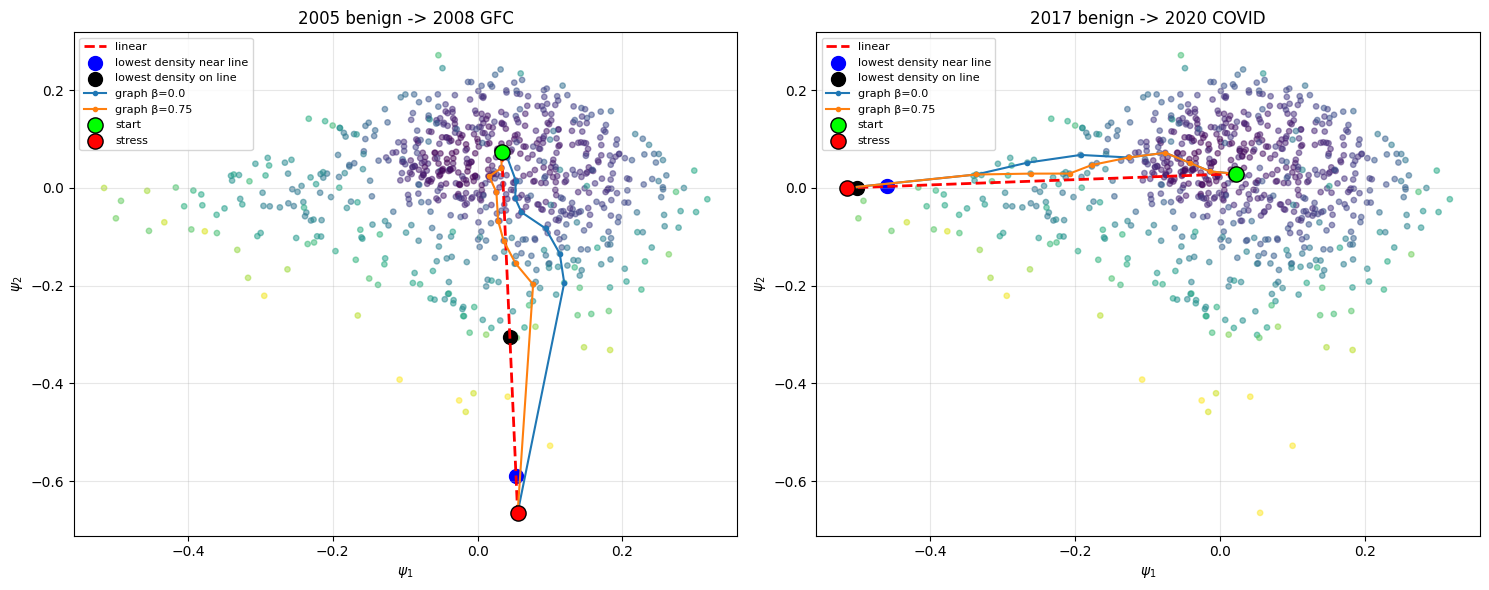

                endpoints         path  interior_min_rho  mean_rho  min_rho_lin  mean_rho_lin  max_NNdist
  2005 benign -> 2008 GFC       linear            0.0292    0.3569       0.0008        0.3163      0.1484
  2005 benign -> 2008 GFC  graph β=0.0            0.1706    1.1720       0.1706        1.1720      0.0000
  2005 benign -> 2008 GFC graph β=0.75            0.3120    1.2282       0.3120        1.2282      0.0000
2017 benign -> 2020 COVID       linear            0.0495    0.7355       0.0541        0.7001      0.0587
2017 benign -> 2020 COVID  graph β=0.0            0.1861    1.2254       0.1861        1.2254      0.0000
2017 benign -> 2020 COVID graph β=0.75            0.1861    1.1469       0.1861        1.1469      0.0000


In [10]:
# [C10] Primary metric: the endpoints are SHARED by all paths and a crisis endpoint is itself
# low-density, so min-over-the-whole-path is dominated by the shared endpoint and cannot
# discriminate. Report (a) min density over INTERIOR points, (b) mean density, (c) max NN distance
# to the cloud. The discriminating signals are mean-density and NN-distance.

median_Dsq = np.median(squareform(pdist(Psi)**2)[np.triu_indices(N,1)])
h = 0.1*median_Dsq; rho, V, scale = graph_degree_density(Psi, h=h)
# I had this function from Phase 4 to find the density of the line, I test it here
def latent_density_at_points(gamma, Psi, h, scale):
    Dsq_query = cdist(gamma, Psi, metric="sqeuclidean")
    rho_query = np.exp(-Dsq_query / h).sum(axis=1)
    rho_query = rho_query/scale
    rho_query_floor = np.maximum(rho_query, 1e-6)
    V_query = -np.log(rho_query_floor)
    return rho_query_floor, V_query

def interior_min_mean(idx_path):
    interior = idx_path[1:-1] if len(idx_path) > 2 else idx_path
    return rho[interior].min(), rho[interior].mean()

def lin_interior_min_mean(s, e, h, n=40):
    lin = np.linspace(Psi[s], Psi[e], n)[1:-1]
    nn = np.array([np.argmin(np.linalg.norm(Psi - p, axis=1)) for p in lin])
    rho_lin, _ = latent_density_at_points(lin, Psi, h, scale)
    min_nn_idx, min_lin_idx = np.argmin(rho[nn]), np.argmin(rho_lin)
    return rho[nn].min(), rho[nn].mean(), rho_lin.min(), rho_lin.mean(), nn_dist_to_cloud(lin).max(), min_nn_idx, min_lin_idx


betas = [0.0, 0.75] #[0.0, 0.5, 1.0, 2.0]
summary = []
fig, axes = plt.subplots(1, len(pairs), figsize=(15, 6))
for ax, (name, (s, e)) in zip(np.atleast_1d(axes), pairs.items()):
    ax.scatter(Psi[:,0], Psi[:,1], c=V, s=15, cmap="viridis", alpha=.5)
    lin = np.linspace(Psi[s], Psi[e], 40)
    ax.plot(lin[:,0], lin[:,1], "r--", lw=2, label="linear")
    lmin, lmean, llmin, llmean, lnn, nn_idx, lin_idx = lin_interior_min_mean(s, e, h)
    ax.scatter(*lin[nn_idx+1, :2], c="blue", s=100, label="lowest density near line")
    ax.scatter(*lin[lin_idx+1, :2], c="k", s=100, label="lowest density on line")
    summary.append((name, "linear", lmin, lmean, llmin, llmean, lnn))
    for beta in betas:
        p = graph_path(beta, s, e); P = Psi[p]
        ax.plot(P[:,0], P[:,1], marker="o", ms=3, label=f"graph β={beta}")
        imin, imean = interior_min_mean(p)
        summary.append((name, f"graph β={beta}", imin, imean, imin, imean, nn_dist_to_cloud(P).max()))
    ax.scatter(*Psi[s,:2], c="lime", s=120, ec="k", zorder=5, label="start")
    ax.scatter(*Psi[e,:2], c="red", s=120, ec="k", zorder=5, label="stress")
    ax.set_title(name); ax.set_xlabel(r"$\psi_1$"); ax.set_ylabel(r"$\psi_2$")
    ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

res = pd.DataFrame(summary, columns=["endpoints","path","interior_min_rho","mean_rho", "min_rho_lin", "mean_rho_lin", "max_NNdist"])
print(res.round(4).to_string(index=False))

### Reading the result

The dissertation claim is operationalised by two columns: **min_density** (higher is better, the path
stays in historically populated regions) and **max_NNdist_to_cloud** (lower is better, the path stays
near observed data). The linear path should show the lowest min-density and the largest
NN-distance (it cuts through the void); the graph paths, even at beta=0, cannot leave the data
because there are no edges across empty regions, and beta>0 pushes them further into dense regions.


The density function looked wrong in the above plot, the black point in the GFC plot looked to be in a high density region. Plotting all 3 dimensions below reveals that it is actually in a low density area and I now believe that the function is working properly.

In [33]:
betas = [0.0, 0.5, 1.0, 2.0]

num_pairs = len(pairs)
fig = make_subplots(rows=1, cols=num_pairs, subplot_titles=list(pairs.keys()),
                    specs=[[{'type': 'scene'} for _ in range(num_pairs)]])

for col_idx, (name, (s, e)) in enumerate(pairs.items(), start=1):
    fig.add_trace(go.Scatter3d(x=Psi[:, 0], y=Psi[:, 1], z=Psi[:, 2], mode='markers', 
                               marker=dict(size=3, color=-V, colorscale='Viridis', 
                                           opacity=0.9, showscale=False), name='Data Cloud',
                                             legendgroup=name, showlegend=(col_idx == 1)), row=1, col=col_idx)
    
    lin = np.linspace(Psi[s], Psi[e], 40)
    lmin, lmean, llmin, llmean, lnn, nn_idx, lin_idx = lin_interior_min_mean(s, e, h)
    
    fig.add_trace(go.Scatter3d(x=lin[:, 0], y=lin[:, 1], z=lin[:, 2],
                               mode='lines', line=dict(color='red', width=4, dash='dash'),
                               name='Linear Path', legendgroup=name, showlegend=(col_idx == 1)),
                               row=1, col=col_idx)
    
    fig.add_trace(go.Scatter3d(x=[lin[nn_idx+1, 0]], y=[lin[nn_idx+1, 1]], z=[lin[nn_idx+1, 2]],
                                mode='markers', marker=dict(size=8, color='blue'), name='Lowest density near line',
                                legendgroup=name, showlegend=(col_idx == 1)), row=1, col=col_idx)
    
    fig.add_trace(go.Scatter3d(x=[lin[lin_idx+1, 0]], y=[lin[lin_idx+1, 1]], z=[lin[lin_idx+1, 2]], mode='markers', 
                               marker=dict(size=8, color='black'), name='Lowest density on line', legendgroup=name, 
                               showlegend=(col_idx == 1)), row=1, col=col_idx)
    
    for beta in betas:
        p = graph_path(beta, s, e); P = Psi[p]
        
        fig.add_trace(go.Scatter3d(x=P[:, 0], y=P[:, 1], z=P[:, 2], mode='lines+markers', marker=dict(size=4),
                                   name=f"graph β={beta}", legendgroup=name, showlegend=(col_idx == 1)), row=1, col=col_idx)
        
    fig.add_trace(go.Scatter3d(x=[Psi[s, 0]], y=[Psi[s, 1]], z=[Psi[s, 2]], mode='markers', 
                               marker=dict(size=10, color='lime', line=dict(color='black', width=2)),
                               name='Start', legendgroup=name, showlegend=(col_idx == 1)), row=1, col=col_idx)
    
    fig.add_trace(
        go.Scatter3d(x=[Psi[e, 0]], y=[Psi[e, 1]], z=[Psi[e, 2]], mode='markers',
                     marker=dict(size=10, color='red', line=dict(color='black', width=2)),
                     name='Stress', legendgroup=name, showlegend=(col_idx == 1)), row=1, col=col_idx)

    fig.update_scenes(xaxis_title=r'psi_1', yaxis_title='psi_2', zaxis_title=r'psi_3', row=1, col=col_idx)

fig.update_layout(height=600, width=500 * num_pairs, margin=dict(l=20, r=20, t=40, b=20), 
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1))

fig.show()